<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

####  Análisis y Procesamiento de Señales
# Trabajo Práctico Nº 1
#### Mariano Gonzalez


### Declaro funcion generador de senoidal y variables globales

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#%%Generador de senoidal
def mi_funcion_sen( vmax, dc, f0, ph, N, fs):
    tt=np.arange(0,N+1,1)*(1/fs)
    xx=dc + vmax*np.sin(2*np.pi*f0*tt + ph)
    return tt,xx 

tono=2000 #f0
fase= np.pi/2  #fase
fss= 100000 #frecuencia de muestreo
nn=100 #muestra
#nn=fss/tono # para ver un solo ciclo

# Ejercicio 1
#### 1) Señal sinusoidal de 2KHz.
#### 2) Misma señal amplificada y desfazada en π/2.

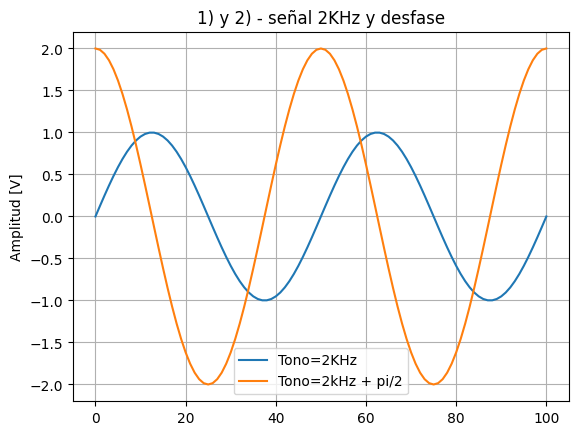

In [3]:
tt, xx = mi_funcion_sen( vmax = 1, dc = 0, f0 = tono, ph=0,N=nn, fs =fss)

tt2, xx2 = mi_funcion_sen( vmax = 2, dc = 0, f0 = tono, ph=fase,N=nn, fs = fss)

plt.figure(1)
plt.clf()
plt.grid()
plt.title('1) y 2) - señal 2KHz y desfase')
plt.plot(xx, label='Tono=2KHz')
plt.plot(xx2, label='Tono=2kHz + pi/2' )
plt.ylabel('Amplitud [V]')
##plt.xlabel('Tiempo [s]')
plt.legend()
plt.show()


#### 3) Misma señal modulada en amplitud por otra señal sinusoidal de la mitad de la frecuencia.


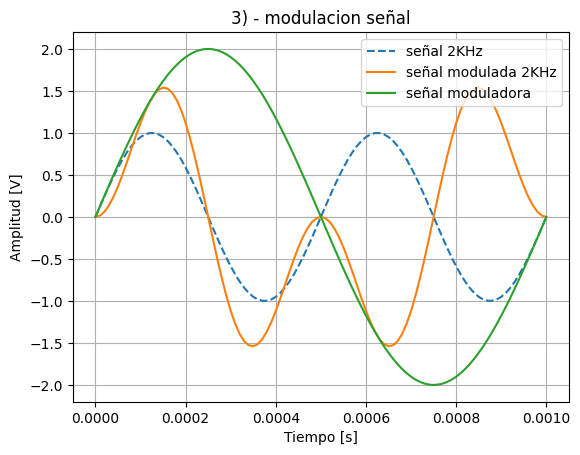

In [4]:
#%%Misma señal (primera) modulada en amplitud por otra señal sinusoidal de la mitad de la frecuencia.
f_mod = tono/2
portadora=xx
tt3, modu = mi_funcion_sen( vmax = 2, dc = 0, f0 = f_mod, ph=0,N=nn, fs = fss)

AM= portadora*modu

plt.figure(2)
plt.clf()
plt.grid()
plt.plot(tt, xx, '--', label='señal 2KHz')
plt.plot(tt, AM, label='señal modulada 2KHz')
plt.plot(tt3, modu, label='señal moduladora')
plt.ylabel('Amplitud [V]')
plt.xlabel('Tiempo [s]')
plt.title('3) - modulacion señal')
plt.legend()
plt.show()


#### 4) Señal anterior recortada al 75% de su amplitud

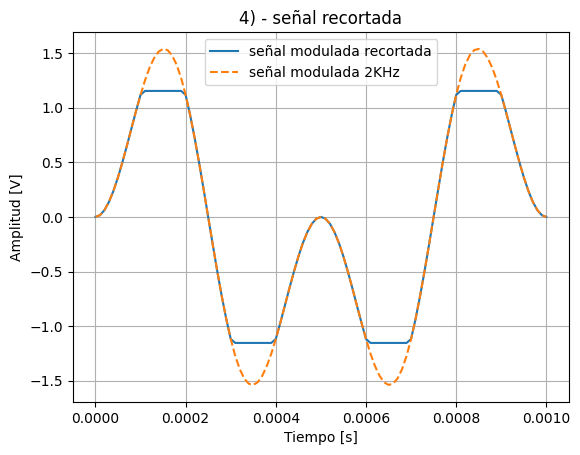

In [5]:
#%% 4) Señal anterior recortada al 75% de su amplitud

limite = 0.75 * np.max(np.abs(AM))
recortada = np.clip(AM, -limite, limite)
plt.figure(3)
plt.clf()
plt.grid()
plt.plot(tt, recortada, label='señal modulada recortada')
plt.plot(tt, AM, '--', label='señal modulada 2KHz')
plt.title('4) - señal recortada')
plt.ylabel('Amplitud [V]')
plt.xlabel('Tiempo [s]')
plt.legend()
plt.show()

#### 5) Una señal cuadrada de 4KHz

Text(0.5, 0, 'Tiempo [s]')

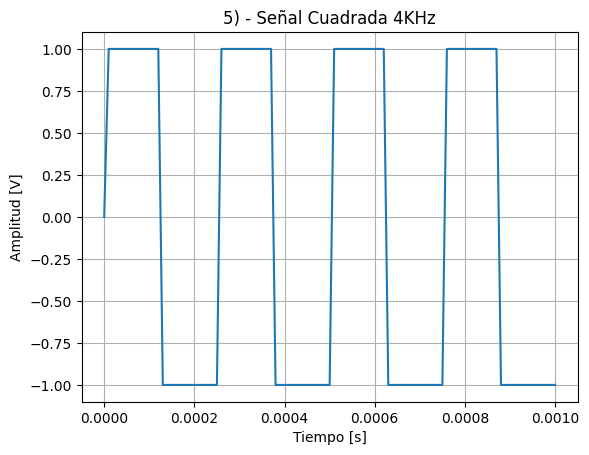

In [6]:
#%% 5) Una señal cuadrada de 4KHz.
tono_cua=4000 #señal de 4KHz
#nn=fss/tono_cua # para ver un solo ciclo
nn=100
tt5, xx5 = mi_funcion_sen( vmax = 2, dc = 0, f0 = tono_cua, ph=0,N=nn, fs = fss)

cuadrada = np.sign(xx5) # np.sign da una cuadrada simétrica entre -1 y +1
plt.figure(4)
plt.clf()
plt.grid()
plt.plot(tt5, cuadrada)
plt.title('5) - Señal Cuadrada 4KHz')
plt.ylabel('Amplitud [V]')
plt.xlabel('Tiempo [s]')

## 6) Un pulso rectangular de 10ms.
Aqui cambiamos el paradigma de usar una senoidal, armo un vector e impongo el la amplitud en el tiempo requerido

Text(0.5, 0, 'Tiempo [s]')

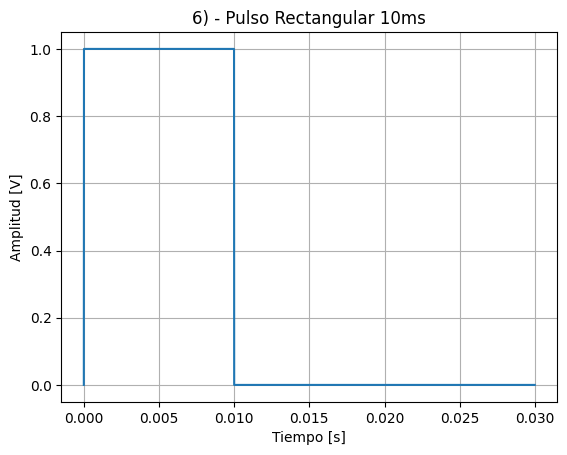

In [7]:
#%% 6) Un pulso rectangular de 10ms
#cambiamos el modo de trabajar, ya no necesito una senoidal

tt_pulso= 0.01 # 10 ms
tt_total=0.03 #duracion del experimento
amplitud=1 # valor alto del pulso, 1V

N= int(fss * tt_total) # vector de tiempo
ttp = np.arange(0, N) * (1/fss) 

pulso = np.zeros(N) # lleno de ceros el vector 
N_pulso = int(fss * tt_pulso) # asigno la duracion
pulso[1:N_pulso] = amplitud # impongo el valor amplitud desde el índice 1 hasta el índice N_pulso-1
# lo hice desde el 1 asi se ve cuando sube, si le quito el 1 arranca en 1 desde 0

plt.figure(5)
plt.clf()
plt.grid()
plt.plot(ttp, pulso)
plt.title('6) - Pulso Rectangular 10ms')
plt.ylabel('Amplitud [V]')
plt.xlabel('Tiempo [s]')
